In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
from pathlib import Path

# Resolve project root regardless of where Jupyter was launched from
_here = Path(os.path.abspath(''))
PROJECT_ROOT = str(_here.parent if _here.name == 'notebooks' else _here)
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

In [ ]:
import sys
import numpy as np
import csv

import torch


import pandas as pd
import pickle
import argparse
from math import isnan
from tqdm import tqdm
from dataclasses import dataclass
from typing import Optional

import random
from huggingface_hub import login
from esm.models.esm3 import ESM3
from esm.sdk.api import ESM3InferenceClient, ESMProtein, GenerationConfig
from esm.utils.structure.protein_chain import ProteinChain
import matplotlib.pyplot as plt
ALPHABET = 'ACDEFGHIKLMNPQRSTVWY'

/home/jupyter-yehlin/.conda/envs/esm3_attention/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from utils.config_esm3 import get_default_config, get_model_configs
from ESM3dG import ESM3dG, ESM3dG_predict

import logging

In [ ]:
def get_pdb(pdb_code=""):
  if pdb_code is None or pdb_code == "":
    raise ValueError("Please provide a PDB code (e.g. 'nanobody_1zvh'), a local file path, or a UniProt ID.")
  elif os.path.isfile(pdb_code):
    return pdb_code
  elif len(pdb_code) == 4:
    os.system(f"wget -qnc https://files.rcsb.org/view/{pdb_code}.pdb")
    return f"{pdb_code}.pdb"
  else:
    os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{pdb_code}-F1-model_v3.pdb")
    return f"AF-{pdb_code}-F1-model_v3.pdb"

## 1. wild-type prediction

In [ ]:
cfg = get_default_config()
cfg.testing.ddg_scanning = False

PDB_NAME = 'nanobody_1zvh'
CHAIN_ID = 'A'
WEIGHT_FILES = [
    "esm3dg_weights/ESM3dG_weights_augmented_1_lora.ckpt",
    "esm3dg_weights/ESM3dG_weights_augmented_2_lora.ckpt",
    "esm3dg_weights/ESM3dG_weights_augmented_3_lora.ckpt",
]

pdb_path = os.path.join(PROJECT_ROOT, "examples", "nanobody_1zvh.cif")
predictions = []
for weight_file in WEIGHT_FILES:
    model = ESM3dG(weight_file, cfg)
    _, pred_dg_avg, combined_seq = ESM3dG_predict(model, pdb_path, CHAIN_ID)
    predictions.append(pred_dg_avg[0])

avg_pred = sum(predictions) / len(predictions)
std_pred = (sum((x - avg_pred) ** 2 for x in predictions) / len(predictions)) ** 0.5
print(f"🧬 {PDB_NAME} Predicted ΔG (kcal/mol): {avg_pred:.2f} ± {std_pred:.2f}")

In [6]:
# import pandas as pd
# df_batch_1 = pd.read_csv("/home/jupyter-yehlin/esm3_attention/weights/checkpoint_unfreeze_warum_up_ddg_bins_lora_dg_and_ddg_sigmoid_5e5_model2_resume_model1_norm/dmsv4_af_dg_epoch07_test_result.csv")
# df_batch_16 = pd.read_csv("/home/jupyter-yehlin/esm3_attention/weights/checkpoint_unfreeze_warum_up_ddg_bins_lora_dg_and_ddg_sigmoid_5e5_model2_resume_model1_norm/archieve/dmsv4_af_dg_epoch07_test_result.csv")


# true_values = df_batch_1['True'].clip(-1, 5)
# pred_values = df_batch_1['Predicted'].clip(-1, 5)
# rmse = np.sqrt(mean_squared_error(true_values, pred_values))
# print(f"RMSE: {rmse:.4f}")

# true_values = df_batch_16['True'].clip(-1, 5)
# pred_values = df_batch_16['Predicted'].clip(-1, 5)
# rmse = np.sqrt(mean_squared_error(true_values, pred_values))
# print(f"RMSE: {rmse:.4f}")


# import matplotlib.pyplot as plt
# plt.scatter(df_batch_1['Predicted'], df_batch_16['Predicted'])
# plt.xlabel('Predicted batch 1')
# plt.ylabel('Predicted batch 16')
# plt.show()

## 2. Mutational scanning

In [ ]:
cfg = get_default_config()
cfg.testing.ddg_scanning = True

PDB_NAME = 'nanobody_1zvh'
CHAIN_ID = 'A'
WEIGHT_FILES = [
    "esm3dg_weights/ESM3dG_weights_augmented_1_lora.ckpt",
    "esm3dg_weights/ESM3dG_weights_augmented_2_lora.ckpt",
    "esm3dg_weights/ESM3dG_weights_augmented_3_lora.ckpt",
]

pdb_path = os.path.join(PROJECT_ROOT, "examples", "nanobody_1zvh.cif")
all_scaled_ddg = []
for weight_file in WEIGHT_FILES:
    model = ESM3dG(weight_file, cfg)
    _, scaled_ddg, combined_seq = ESM3dG_predict(model, pdb_path, CHAIN_ID, ddg_scanning=True)
    all_scaled_ddg.append(scaled_ddg)

scaled_pred_mutant_ddg = torch.stack(all_scaled_ddg).mean(dim=0)

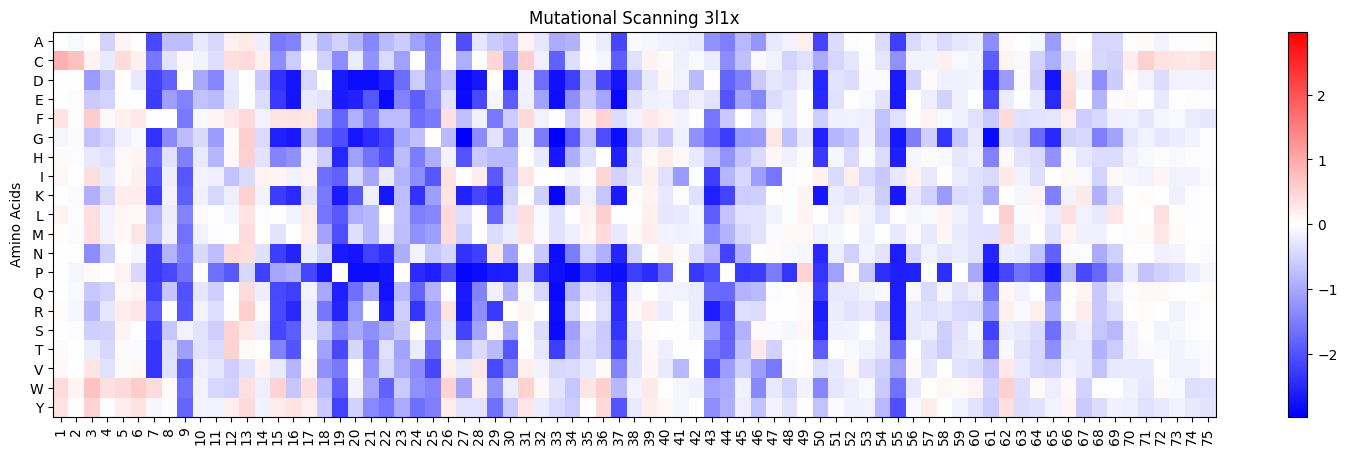

In [6]:
mean_results = np.mean(scaled_pred_mutant_ddg.detach().cpu().numpy(), axis=-1).T[0]
height, width = mean_results.shape
fig_width = min(max(width/4, 8), 25)
fig_height = min(max(height/4, 3), 8)
plt.figure(figsize=(fig_width, fig_height))

vmin = mean_results.min()
vmax = mean_results.max()
divergence = max(abs(vmin), abs(vmax))

plt.imshow(mean_results, 
           aspect='auto',
           cmap='bwr',
           vmin=-divergence,
           vmax=divergence)

L = mean_results.shape[1]
plt.xticks(ticks=np.arange(L), labels=np.arange(1, L + 1), rotation=90)
plt.yticks(ticks=range(len(ALPHABET)), labels=ALPHABET)
plt.ylabel("Amino Acids")
plt.title("Mutational Scanning {}".format(PDB_NAME))
plt.colorbar()
plt.show()

In [ ]:
cfg = get_default_config()
cfg.testing.ddg_scanning = False

PDB_NAME = 'nanobody_1zvh'
CHAIN_ID = 'A'
WEIGHTS_DIR = "esm3dg_weights"
WEIGHT_FILES = [
    "ESM3dG_weights_augmented_1_lora.ckpt",
    "ESM3dG_weights_augmented_2_lora.ckpt", 
    "ESM3dG_weights_augmented_3_lora.ckpt"
]

# Get PDB path once
pdb_path = os.path.join(PROJECT_ROOT, "examples", "nanobody_1zvh.cif")

# Load all models first
models = []
for weight_file in WEIGHT_FILES:
    weight_path = f"{WEIGHTS_DIR}/{weight_file}"
    model = ESM3dG(weight_path, cfg)
    models.append(model)
# Run predictions for each model and collect results
predictions = []
for i, (model, weight_file) in enumerate(zip(models, WEIGHT_FILES), 1):
    pred_dg_per_res, pred_dg_avg, combined_seq = ESM3dG_predict(model, pdb_path, CHAIN_ID)
    pred_value = pred_dg_avg[0]
    predictions.append(pred_value)
    print(f"🧬 Model {i}: {PDB_NAME} Predicted ΔG (kcal/mol) using {weight_file}: {pred_value:.2f}")

# Calculate and print average and standard deviation
avg_pred = sum(predictions) / len(predictions)
std_pred = (sum((x - avg_pred) ** 2 for x in predictions) / len(predictions)) ** 0.5
print(f"\n📊 Ensemble prediction for {PDB_NAME}:")
print(f"   Average ΔG: {avg_pred:.2f} ± {std_pred:.2f} kcal/mol")